## <span style="color:#6A4C93;">Data Analysis and Visualization &ndash; Lab 2</span>

**Name:** Ahmed Bilal Azhar &nbsp;|&nbsp; **Roll No:** 23I-2581 &nbsp;|&nbsp; **Section:** DS-A &nbsp;|&nbsp; **Dataset:** Tips dataset

### <span style="color:#3A86FF;">Import Libraries</span>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.edgecolor'] = '#4a4a4a'
plt.rcParams['grid.alpha'] = 0.35


COLORS = ['#FF6B6B', '#4ECDC4', '#FFD166', '#6A4C93', '#06D6A0', '#F72585', '#3A86FF', '#FB8500']

### <span style="color:#3A86FF;">Load Dataset</span>

In [58]:
df = sns.load_dataset('tips')
print(df.head())

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4


In [59]:
print(df.shape)

(244, 7)


In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [61]:
print(df.isnull().sum())

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64


In [62]:
print(df.duplicated().sum())

1


In [63]:
df = df.drop_duplicates()
df = df.reset_index(drop=True)
print(df.shape)

(243, 7)


#### <span style="color:#FF6B6B;">Task 1: Bar Chart</span>

In [64]:
day_avg = df.groupby('day', observed=True)['total_bill'].mean()
print(day_avg.round(2))

day
Thur    17.76
Fri     17.15
Sat     20.44
Sun     21.41
Name: total_bill, dtype: float64


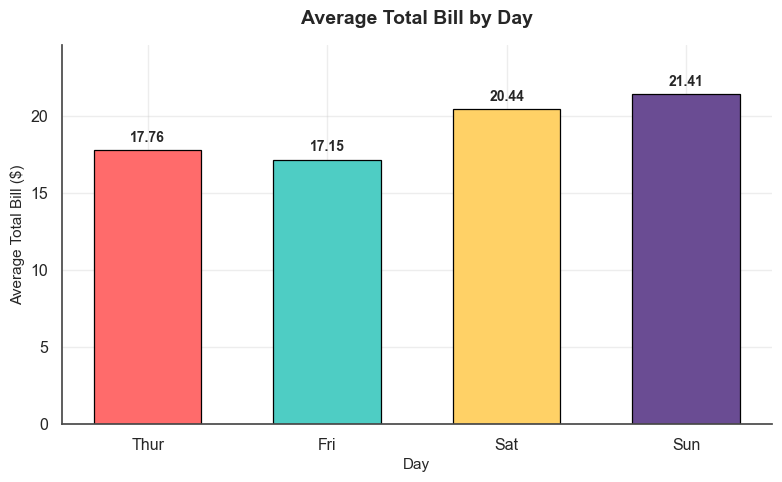

In [65]:
plt.figure(figsize=(8, 5))
bars = plt.bar(day_avg.index, day_avg.values, color=COLORS[:len(day_avg)],
                edgecolor='black', linewidth=0.9, width=0.6)
plt.bar_label(bars, fmt='%.2f', padding=4, fontsize=10, fontweight='bold')
plt.xlabel('Day')
plt.ylabel('Average Total Bill ($)')
plt.title('Average Total Bill by Day', pad=15)
plt.ylim(0, day_avg.max() * 1.15)
sns.despine()
plt.tight_layout()
plt.show()

#### <span style="color:#FF6B6B;">Task 2: Count Plot</span>

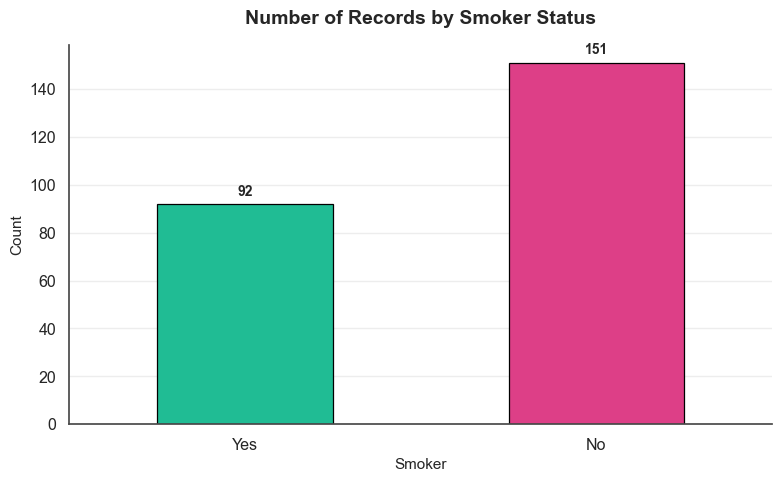

In [66]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='smoker', hue='smoker', palette=['#06D6A0', '#F72585'],
                    edgecolor='black', linewidth=0.9, width=0.5, legend=False)
for container in ax.containers:
    ax.bar_label(container, padding=4, fontsize=10, fontweight='bold')
plt.xlabel('Smoker')
plt.ylabel('Count')
plt.title('Number of Records by Smoker Status', pad=15)
sns.despine()
plt.tight_layout()
plt.show()

In [67]:
smoker_counts = df['smoker'].value_counts()
print(smoker_counts)
most_common = smoker_counts.idxmax()
print('most common category is', most_common)

smoker
No     151
Yes     92
Name: count, dtype: int64
most common category is No


#### <span style="color:#FF6B6B;">Task 3: Histogram</span>

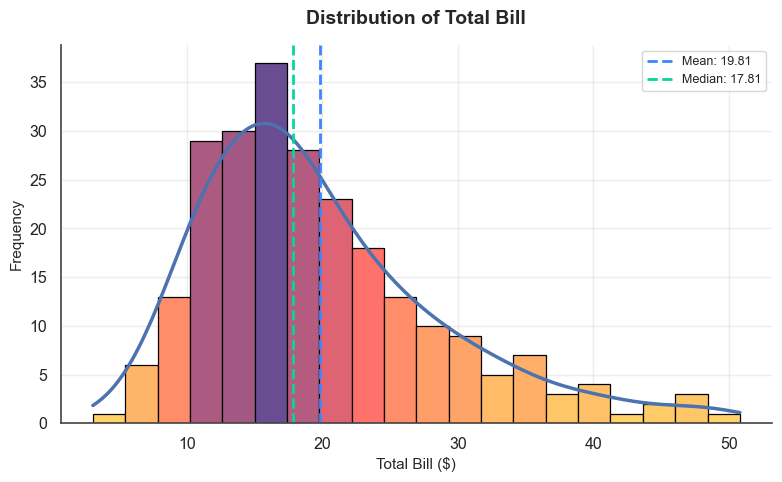

In [68]:
plt.figure(figsize=(8, 5))
ax = sns.histplot(data=df, x='total_bill', bins=20, edgecolor='black', linewidth=0.9,
                   kde=True, line_kws={'linewidth': 2.5, 'color': '#2c3e50'})

# color each bar with a gradient based on its height, for a colorful look
cmap = LinearSegmentedColormap.from_list('sunset', ['#FFD166', '#FF6B6B', '#6A4C93'])
heights = [p.get_height() for p in ax.patches]
norm = plt.Normalize(min(heights), max(heights))
for p in ax.patches:
    p.set_facecolor(cmap(norm(p.get_height())))

mean_val = df['total_bill'].mean()
median_val = df['total_bill'].median()
plt.axvline(mean_val, color='#3A86FF', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
plt.axvline(median_val, color='#06D6A0', linestyle='--', linewidth=2, label=f'Median: {median_val:.2f}')
plt.xlabel('Total Bill ($)')
plt.ylabel('Frequency')
plt.title('Distribution of Total Bill', pad=15)
plt.legend(frameon=True, fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()

In [69]:
bill_skew = df['total_bill'].skew()
print(round(bill_skew, 2))
if bill_skew > 0.5:
    print('total bill is right skewed, most bills are low to moderate with a long tail of a few very high bills')
elif bill_skew < -0.5:
    print('total bill is left skewed, most bills are high with a long tail of a few very low bills')
else:
    print('total bill is roughly symmetric with no strong tail on either side')

1.13
total bill is right skewed, most bills are low to moderate with a long tail of a few very high bills


#### <span style="color:#FF6B6B;">Task 4: Box Plot</span>

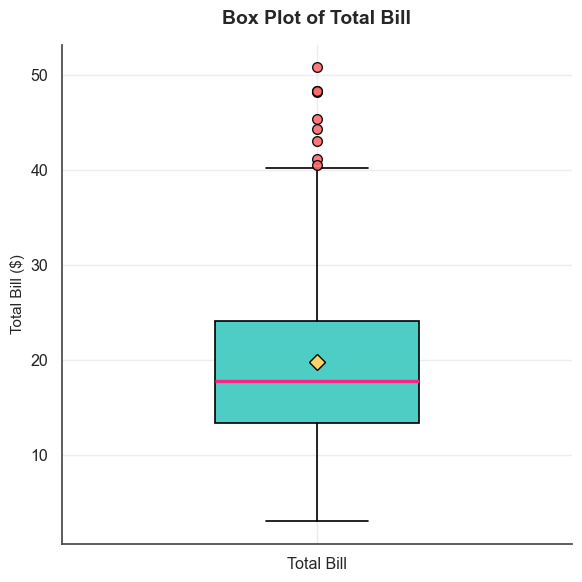

In [70]:
plt.figure(figsize=(6, 6))
box_result = plt.boxplot(df['total_bill'], patch_artist=True, widths=0.4,
    boxprops=dict(facecolor='#4ECDC4', edgecolor='black', linewidth=1.2),
    medianprops=dict(color='#F72585', linewidth=2.4),
    whiskerprops=dict(color='black', linewidth=1.2),
    capprops=dict(color='black', linewidth=1.2),
    flierprops=dict(marker='o', markerfacecolor='#FF6B6B', markeredgecolor='black',
                     markersize=7, alpha=0.9),
    showmeans=True,
    meanprops=dict(marker='D', markerfacecolor='#FFD166', markeredgecolor='black', markersize=8))
plt.xticks([1], ['Total Bill'])
plt.ylabel('Total Bill ($)')
plt.title('Box Plot of Total Bill', pad=15)
sns.despine()
plt.tight_layout()
plt.show()

In [71]:
outlier_points = box_result['fliers'][0].get_ydata()
print('number of outlier points visible on the box plot')
print(len(outlier_points))

number of outlier points visible on the box plot
9


#### <span style="color:#FF6B6B;">Task 5: IQR Method</span>

In [72]:
q1 = df['total_bill'].quantile(0.25)
q3 = df['total_bill'].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
outliers = df[(df['total_bill'] < lower) | (df['total_bill'] > upper)]
print(len(outliers))

9


In [73]:
if len(outliers) == len(outlier_points):
    print('the IQR count matches the number of points visible on the box plot')
else:
    print('the IQR count does not match the box plot count')

the IQR count matches the number of points visible on the box plot


#### <span style="color:#FF6B6B;">Task 6: Z-score Method</span>

In [74]:
df['zscore'] = stats.zscore(df['total_bill'])
outliers_z = df[df['zscore'].abs() > 3]
print(len(outliers_z))

4


In [75]:
if len(outliers) == len(outliers_z):
    print('IQR and zscore flagged the same number of outliers')
elif len(outliers) > len(outliers_z):
    print('IQR flagged more outliers than zscore because total_bill is right skewed and the skew inflates the standard deviation which hides some outliers under the zscore method')
else:
    print('zscore flagged more outliers than IQR')

df = df.drop(columns='zscore')

IQR flagged more outliers than zscore because total_bill is right skewed and the skew inflates the standard deviation which hides some outliers under the zscore method


#### <span style="color:#FF6B6B;">Task 7: Scatter Plot</span>

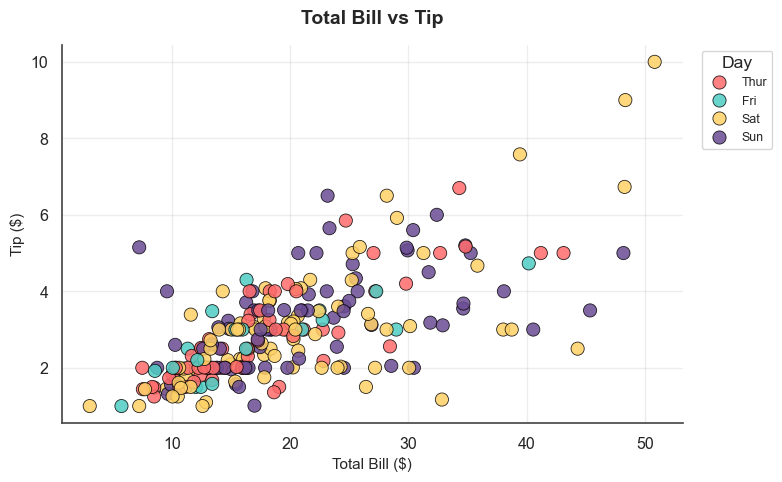

In [76]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='total_bill', y='tip', hue='day',
                 palette=COLORS[:4], s=90, alpha=0.85, edgecolor='black', linewidth=0.6)
plt.xlabel('Total Bill ($)')
plt.ylabel('Tip ($)')
plt.title('Total Bill vs Tip', pad=15)
plt.legend(title='Day', frameon=True, fontsize=9, loc='upper left', bbox_to_anchor=(1.02, 1))
sns.despine()
plt.tight_layout()
plt.show()

In [77]:
corr = df['total_bill'].corr(df['tip'])
print(round(corr, 2))
if corr > 0.3:
    print('there is a positive relationship, as total bill increases the tip tends to increase too')
elif corr < -0.3:
    print('there is a negative relationship')
else:
    print('there is no clear relationship')

0.67
there is a positive relationship, as total bill increases the tip tends to increase too


#### <span style="color:#FF6B6B;">Task 8: Line and Area Chart</span>

In [78]:
print(day_avg.round(2))

day
Thur    17.76
Fri     17.15
Sat     20.44
Sun     21.41
Name: total_bill, dtype: float64


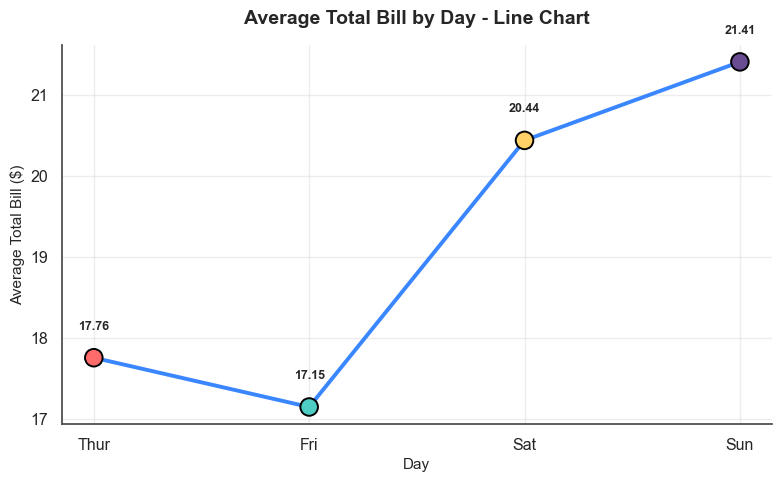

In [79]:
plt.figure(figsize=(8, 5))
plt.plot(day_avg.index, day_avg.values, linewidth=2.8, color='#3A86FF', zorder=2)
plt.scatter(day_avg.index, day_avg.values, s=160, c=COLORS[:4],
            edgecolor='black', linewidth=1.4, zorder=3)
for x, y in zip(day_avg.index, day_avg.values):
    plt.text(x, y + 0.35, f'{y:.2f}', ha='center', fontsize=9, fontweight='bold')
plt.xlabel('Day')
plt.ylabel('Average Total Bill ($)')
plt.title('Average Total Bill by Day - Line Chart', pad=15)
sns.despine()
plt.tight_layout()
plt.show()

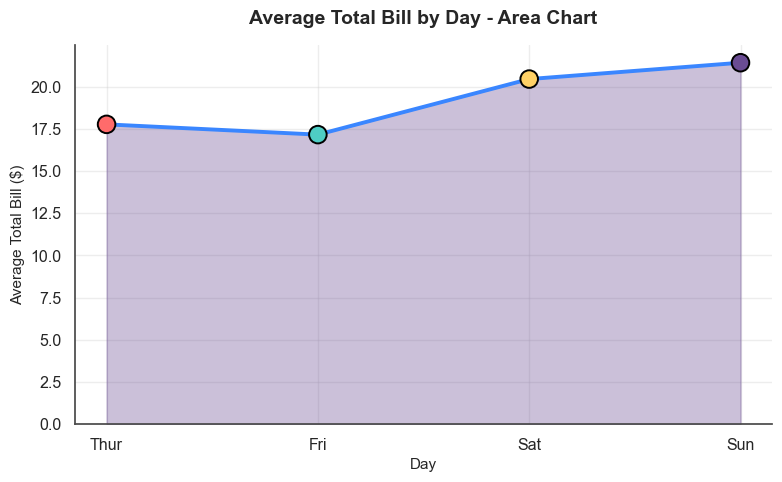

In [80]:
plt.figure(figsize=(8, 5))
plt.fill_between(day_avg.index, day_avg.values, color='#6A4C93', alpha=0.35)
plt.plot(day_avg.index, day_avg.values, linewidth=2.8, color='#3A86FF', zorder=2)
plt.scatter(day_avg.index, day_avg.values, s=160, c=COLORS[:4],
            edgecolor='black', linewidth=1.4, zorder=3)
plt.xlabel('Day')
plt.ylabel('Average Total Bill ($)')
plt.title('Average Total Bill by Day - Area Chart', pad=15)
plt.ylim(bottom=0)
sns.despine()
plt.tight_layout()
plt.show()

In [81]:
print('day has a natural order from Thursday to Sunday so it can be treated as an ordered variable for a line chart')
print('the line chart y axis is auto scaled and does not start at zero so the rise from Friday to Sunday looks steep')
print('the area chart fills down to zero which anchors the eye to the real baseline and the same rise looks much smaller next to the full bar')

day has a natural order from Thursday to Sunday so it can be treated as an ordered variable for a line chart
the line chart y axis is auto scaled and does not start at zero so the rise from Friday to Sunday looks steep
the area chart fills down to zero which anchors the eye to the real baseline and the same rise looks much smaller next to the full bar


#### <span style="color:#FF6B6B;">Task 9: Graphical Integrity Check</span>

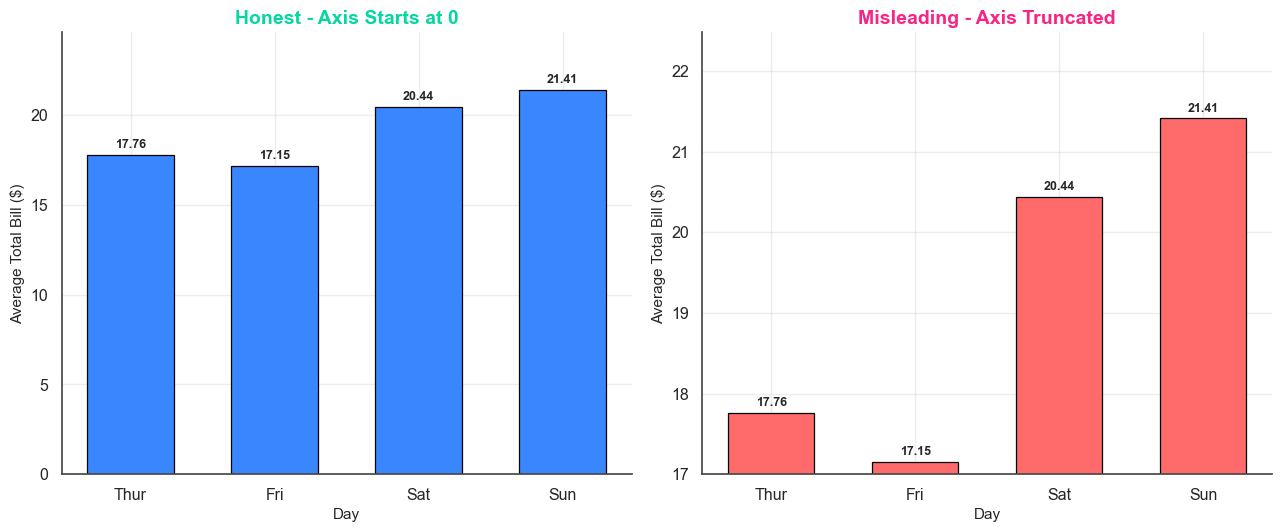

In [82]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5.5))

bars0 = ax[0].bar(day_avg.index, day_avg.values, color='#3A86FF', edgecolor='black',
                   linewidth=0.9, width=0.6)
ax[0].bar_label(bars0, fmt='%.2f', padding=3, fontsize=9, fontweight='bold')
ax[0].set_title('Honest - Axis Starts at 0', fontweight='bold', color='#06D6A0')
ax[0].set_xlabel('Day')
ax[0].set_ylabel('Average Total Bill ($)')
ax[0].set_ylim(0, day_avg.max() * 1.15)

bars1 = ax[1].bar(day_avg.index, day_avg.values, color='#FF6B6B', edgecolor='black',
                   linewidth=0.9, width=0.6)
ax[1].bar_label(bars1, fmt='%.2f', padding=3, fontsize=9, fontweight='bold')
ax[1].set_ylim(bottom=17)
ax[1].set_title('Misleading - Axis Truncated', fontweight='bold', color='#F72585')
ax[1].set_xlabel('Day')
ax[1].set_ylabel('Average Total Bill ($)')

sns.despine()
plt.tight_layout()
plt.show()

### <span style="color:#3A86FF;">Save Cleaned Dataset</span>

In [84]:
df.to_csv('23I-2581_DS-A_Lab02.csv', index=False)
print('saved')

saved
